# Random Forest Source-Zone Workflow v1

Clean notebook for RF source-zone classification and tuning. The notebook uses the repo pipeline and keeps heavy tuning optional.

Default setup: polygon `3` is used for training/tuning, polygon `4` is held out for final testing. The target is the physics + DoD source label configured in YAML.

## 1. Setup

In [3]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Find repo root whether the notebook is run from repo root or notebooks/.
REPO = Path.cwd().resolve()
for candidate in [REPO, *REPO.parents]:
    if (candidate / "src" / "pci_source_zones").exists():
        REPO = candidate
        break

if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from pci_source_zones.config import load_config
from pci_source_zones.inputs import read_raster
from pci_source_zones.ml.dataset import build_ml_dataset
from pci_source_zones.ml.workflow import run_ml_workflow
from pci_source_zones.ml.tuning import run_tuning_workflow

print("repo:", REPO)


repo: /home/abdullah/pci-source-zones


## 2. Config

In [4]:

CONFIG = REPO / "config" / "ml_random_forest.yaml"
TUNE_CONFIG = REPO / "config" / "ml_random_forest_tune.yaml"

cfg = load_config(CONFIG)
tune_cfg = load_config(TUNE_CONFIG)

print("config:", CONFIG)
print("tune config:", TUNE_CONFIG)
print("model:", cfg["ml"]["model"]["type"])
print("target:", cfg["ml"]["target"])
print("split:", cfg["ml"]["split"])
print("tuning search:", tune_cfg["ml"]["tuning"]["search_method"])
print("tuning cv:", tune_cfg["ml"]["tuning"]["cv"])


config: /home/abdullah/pci-source-zones/config/ml_random_forest.yaml
tune config: /home/abdullah/pci-source-zones/config/ml_random_forest_tune.yaml
model: random_forest
target: {'type': 'physics_dod', 'c_min': 5, 'c_channel': 120, 'erosion_threshold_m': -0.55, 'exclude_channels_from_training': True, 'export': True, 'nodata': 255}
split: {'method': 'polygons', 'seed': 42, 'test_size': 0.2, 'val_size': 0.1, 'negative_to_positive_ratio': 3, 'polygons': {'path': '/mnt/c/Users/amehedi/Downloads/dunne_lithology_polygons_unlabeled.gpkg', 'id_field': 'poly_id', 'train_ids': [3], 'test_ids': [4]}}
tuning search: random_search
tuning cv: {'method': 'spatial_blocks', 'n_splits': 5, 'block_size_m': 250, 'seed': 42}


## 3. Inspect Dataset And Splits

In [5]:
def split_summary_table(data):
    rows = []
    for split, idx in data.splits.items():
        yy = data.y[idx]
        rows.append({
            "split": split,
            "cells": len(idx),
            "positive": int((yy == 1).sum()),
            "negative": int((yy == 0).sum()),
            "positive_fraction": float((yy == 1).mean()) if len(yy) else np.nan,
        })
    return pd.DataFrame(rows)


def metrics_table(metrics):
    rows = []
    for split, vals in metrics.items():
        row = {"split": split}
        for key in ["n", "positive", "negative", "accuracy", "balanced_accuracy", "mcc", "precision", "recall", "f1", "roc_auc"]:
            if key in vals:
                row[key] = vals[key]
        rows.append(row)
    return pd.DataFrame(rows)


def plot_three_maps(target_path, probability_path, class_path, title):
    target, _ = read_raster(target_path)
    prob, _ = read_raster(probability_path)
    klass, _ = read_raster(class_path)

    klass_plot = np.where(klass == 255, np.nan, klass)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(np.where(target == 255, np.nan, target), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Target")

    im = axes[1].imshow(prob, cmap="viridis", vmin=0, vmax=1)
    axes[1].set_title("Predicted probability")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    axes[2].imshow(klass_plot, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Binary class")

    for ax in axes:
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


data = build_ml_dataset(cfg)

print("target rule:", data.target_data.positive_rule)
print("X shape:", data.X.shape)
print("features:", list(data.X.columns))
display(split_summary_table(data))


target rule: 5 <= G < 120 and DoD < -0.55
X shape: (473933, 17)
features: ['slope', 'drainage_area', 'soil_thickness', 'soil_density', 'sand_total', 'silt_total', 'clay_total', 'porosity', 'field_capacity', 'saturated_water_content', 'soil_transmissivity', 'saturated_hydraulic_conductivity', 'et_diff', 'ndvi_diff', 'burn_severity', 'soil_texture', 'landcover']


,split,cells,positive,negative,positive_fraction
0,train,42968,10742,32226,0.250000
1,test,30233,2347,27886,0.077630
2,val,7350,1194,6156,0.162449


## 4. Train Baseline Random Forest And Export Products

In [6]:

result = run_ml_workflow(cfg, model_name="random_forest")

for key, value in result.items():
    print(f"{key}: {value}")

model_name: random_forest
output_dir: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/random_forest
target: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/random_forest/ml_target_2.tif
probability: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/random_forest/random_forest_source_probability.tif
class: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/random_forest/random_forest_source_class_p0p5.tif
model: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/random_forest/random_forest_model.joblib
metrics: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/random_forest/random_forest_metrics.json
feature_scores: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/random_forest/random_forest_feature_scores.csv
split_summary: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/random_forest/split_summary.csv
feature_names: ['slope', 'drainage_area', 'soil_thickness', 'soil_density', 'sand_total', 'silt_total', 'clay_total', 'porosity', 'field_capa

## 5. Baseline Metrics

In [ ]:

metrics = json.loads(Path(result["metrics"]).read_text())
display(metrics_table(metrics))

for split, vals in metrics.items():
    print("\n", split, "confusion matrix [0,1] rows/cols")
    print(np.array(vals["confusion_matrix"]))

,split,n,positive,negative,accuracy,balanced_accuracy,mcc,precision,recall,f1,roc_auc
0,train,42968,10742,32226,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,test,30233,2347,27886,0.921609,0.501148,0.017124,0.205128,0.003409,0.006706,0.592474
2,val,7350,1194,6156,0.871429,0.722072,0.489001,0.631468,0.500838,0.558617,0.876453



 train confusion matrix [0,1] rows/cols
[[32226     0]
 [    0 10742]]

 test confusion matrix [0,1] rows/cols
[[27855    31]
 [ 2339     8]]

 val confusion matrix [0,1] rows/cols
[[5807  349]
 [ 596  598]]


saved: /mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/random_forest/rf_inferred_effective_C.tif
Ceff min/median/mean/max: 0.040005296451463716 11.967039243440212 19.94798889944455 126.79894380452745


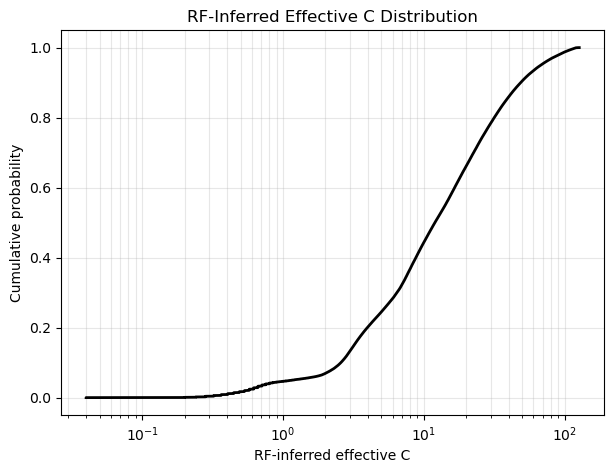

In [8]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from pci_source_zones.ml.targets import _read_g
from pci_source_zones.inputs import read_raster
from pci_source_zones.ml.outputs import write_float_raster

# -----------------------------
# RF-inferred effective C
# -----------------------------

# RF source probability raster
rf_prob, _ = read_raster(result["probability"])

# terrain forcing raster: G = a S^alpha
G, profile = _read_g(cfg)

# smoothing/sharpness parameter in:
# P = 1 / (1 + exp[-k * (G - Ceff)])
k = 1.0

# avoid logit problems at P = 0 or P = 1
p = np.clip(rf_prob, 0.001, 0.999)

# logit(P)
logit_p = np.log(p / (1 - p))

# inferred effective C
Ceff = G - (logit_p / k)

# keep only meaningful finite positive values
valid_ceff = np.isfinite(Ceff) & (Ceff > 0)

# save Ceff raster
out_dir = Path(result["output_dir"])
ceff_path = out_dir / "rf_inferred_effective_C.tif"
ceff_path = write_float_raster(ceff_path, Ceff.astype("float32"), profile)

print("saved:", ceff_path)
print(
    "Ceff min/median/mean/max:",
    np.nanmin(Ceff[valid_ceff]),
    np.nanmedian(Ceff[valid_ceff]),
    np.nanmean(Ceff[valid_ceff]),
    np.nanmax(Ceff[valid_ceff]),
)

# -----------------------------
# Ceff CDF plot
# -----------------------------

Ceff_sorted = np.sort(Ceff[valid_ceff])
cdf = np.arange(1, len(Ceff_sorted) + 1) / len(Ceff_sorted)

plt.figure(figsize=(7, 5))
plt.plot(Ceff_sorted, cdf, color="black", linewidth=2)
plt.xscale("log")
plt.xlabel("RF-inferred effective C")
plt.ylabel("Cumulative probability")
plt.title("RF-Inferred Effective C Distribution")
plt.grid(True, which="both", alpha=0.3)
plt.show()

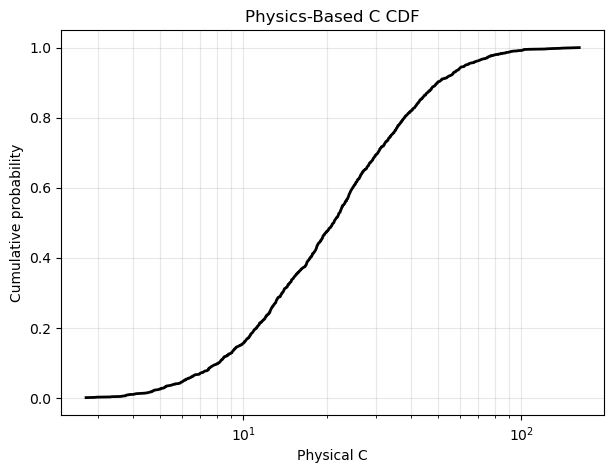

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

C_PATH = "/mnt/c/Users/amehedi/Downloads/source_area_workflow/c_samples.csv"

c_table = pd.read_csv(C_PATH)
C_samples = np.sort(c_table["C"].dropna().values)

cdf = np.arange(1, len(C_samples) + 1) / len(C_samples)

plt.figure(figsize=(7, 5))
plt.plot(C_samples, cdf, color="black", linewidth=2)
plt.xscale("log")
plt.xlabel("Physical C")
plt.ylabel("Cumulative probability")
plt.title("Physics-Based C CDF")
plt.grid(True, which="both", alpha=0.3)
plt.show()

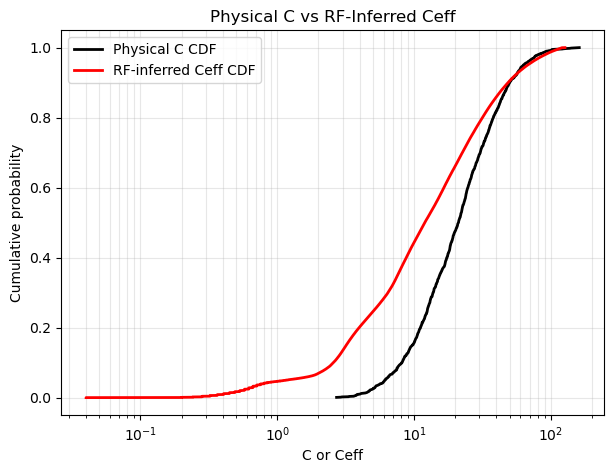

In [12]:
ceff_cdf = np.arange(1, len(Ceff_sorted) + 1) / len(Ceff_sorted)

plt.figure(figsize=(7, 5))
plt.plot(C_samples, cdf, color="black", linewidth=2, label="Physical C CDF")
plt.plot(Ceff_sorted, ceff_cdf, color="red", linewidth=2, label="RF-inferred Ceff CDF")

plt.xscale("log")
plt.xlabel("C or Ceff")
plt.ylabel("Cumulative probability")
plt.title("Physical C vs RF-Inferred Ceff")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

## 6. Baseline Feature Importance

In [ ]:

importance = pd.read_csv(result["feature_scores"])
display(importance.head(25))

plot_df = importance.sort_values("importance", ascending=True).tail(25)
plt.figure(figsize=(8, max(4, 0.35 * len(plot_df))))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("RF feature importance")
plt.title("Random forest feature importance")
plt.tight_layout()
plt.show()


## 7. Baseline Output Maps

In [ ]:

plot_three_maps(
    result["target"],
    result["probability"],
    result["class"],
    "Random forest baseline source-zone outputs",
)


## 8. Optional Hyperparameter Tuning

This can be expensive. It uses the train polygon only, spatial-block CV inside that polygon, and keeps polygon `4` for final testing.

In [ ]:

RUN_TUNING = False  # Change to True when you are ready for a longer run.

if RUN_TUNING:
    tuned_result = run_tuning_workflow(tune_cfg, model_name="random_forest")
    for key, value in tuned_result.items():
        print(f"{key}: {value}")
else:
    tuned_result = None
    print("Tuning skipped. Set RUN_TUNING = True to run spatial-CV random search.")


## 9. Inspect Tuning Outputs If They Exist

In [ ]:

# This lets you review tuning results from a previous script or notebook run.
tuned_dir = Path("/mnt/c/Users/amehedi/Downloads/source_area_workflow/ml/random_forest_tuned")
summary_path = tuned_dir / "random_forest_tuned_tuning_summary.json"
best_path = tuned_dir / "random_forest_tuned_best_params.json"
cv_path = tuned_dir / "random_forest_tuned_cv_results.csv"
metrics_path = tuned_dir / "random_forest_tuned_metrics.json"

if summary_path.exists():
    print("summary")
    print(json.dumps(json.loads(summary_path.read_text()), indent=2))
if best_path.exists():
    print("\nbest params")
    print(json.dumps(json.loads(best_path.read_text()), indent=2))
if cv_path.exists():
    cv_results = pd.read_csv(cv_path)
    display(cv_results.head(10))
if metrics_path.exists():
    tuned_metrics = json.loads(metrics_path.read_text())
    display(metrics_table(tuned_metrics))
if not summary_path.exists():
    print("No tuned output found yet:", tuned_dir)


## 10. Partial Dependence From Baseline RF

Use this for process interpretation only after checking held-out performance.

In [ ]:

from joblib import load
from sklearn.inspection import PartialDependenceDisplay

PDP_FEATURES = ["soil_thickness", "ndvi_diff", "et_diff"]
model_bundle = load(result["model"])
rf_model = model_bundle["model"]

pdp_features = [name for name in PDP_FEATURES if name in data.X.columns]
if pdp_features:
    rows = data.splits["train"]
    sample = data.X.iloc[rows].sample(
        n=min(20000, len(rows)),
        random_state=cfg["ml"]["split"].get("seed", 42),
    )
    PartialDependenceDisplay.from_estimator(
        rf_model,
        sample,
        features=pdp_features,
        kind="average",
        grid_resolution=30,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No requested PDP features found:", PDP_FEATURES)
